In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

In [2]:
# --- Load MovieLens 1M ---
import os
import glob

# Automatically detect MovieLens 1M dataset path (local or Kaggle)
dataset_path = '/kaggle/input/datasets/rrickyroger/movielens-1m'
if not os.path.exists(os.path.join(dataset_path, 'ratings.dat')):
    kaggle_candidates = glob.glob('/kaggle/input/**/ratings.dat', recursive=True)
    if kaggle_candidates:
        dataset_path = os.path.dirname(kaggle_candidates[0])
    else:
        # Check standard Kaggle path
        fallback_path = '/kaggle/input/datasets/rrickyroger/movielens-1m'
        if os.path.exists(fallback_path):
            dataset_path = fallback_path

print(f"Using dataset path: {dataset_path}")
ratings = pd.read_csv(
    os.path.join(dataset_path, 'ratings.dat'),
    sep='::',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    engine='python'
)
movies = pd.read_csv(
    os.path.join(dataset_path, 'movies.dat'),
    sep='::',
    names=['movie_id', 'title', 'genres'],
    engine='python',
    encoding='latin-1'
)

Using dataset path: /kaggle/input/datasets/rrickyroger/movielens-1m


In [ ]:
# --- Build user sequences (sorted by timestamp) ---
ratings = ratings.sort_values(['user_id', 'timestamp'])
user_sequences = ratings.groupby('user_id')['movie_id'].apply(list).to_dict()

# Filter users with fewer than 10 interactions
user_sequences = {u: seq for u, seq in user_sequences.items() if len(seq) >= 10}

#THIS IS TARGETING EXPERIENCED USERS NOT THE COLD START ONES 


In [4]:
# --- Remap item IDs to contiguous range (1-indexed, 0 reserved for MASK) ---
all_items = sorted(set(item for seq in user_sequences.values() for item in seq))
item2idx = {item: idx + 1 for idx, item in enumerate(all_items)}  # 1-indexed
idx2item = {idx: item for item, idx in item2idx.items()}
num_items = len(all_items) + 1  # +1 for MASK token at index 0

# Remap sequences
for u in user_sequences:
    user_sequences[u] = [item2idx[i] for i in user_sequences[u]]

# --- Segment into fixed-length sequences of 16 ---
SEQ_LEN = 16
MASK_TOKEN = 0

In [ ]:
def segment_sequences(user_sequences, seq_len=16):
    sequences = []
    user_ids = []
    for user_id, seq in user_sequences.items():
        # Create overlapping windows
        for i in range(0, len(seq) - seq_len + 1, seq_len):
            sequences.append(seq[i:i+seq_len])
            user_ids.append(user_id)

    #THIS IS BUILDING NON-OVERLAPPING BLOCKS OF SIZE = SEQ_LEN -- A MISMATCH TO THE COMMENT 

        # Handle remaining items (pad if needed)
        remaining = len(seq) % seq_len
        if remaining > 0:
            last_seq = seq[-remaining:] + [MASK_TOKEN] * (seq_len - remaining)
            sequences.append(last_seq)
            user_ids.append(user_id)
    return sequences, user_ids

sequences, user_ids = segment_sequences(user_sequences, SEQ_LEN)

# --- Build genre labels for downstream classification ---
# Map movie_id -> most frequent genre
movie_genre = {}
for _, row in movies.iterrows():
    movie_genre[row['movie_id']] = row['genres'].split('|')[0]  # Primary genre

# For each sequence, compute favorite genre (most frequent genre in sequence)
genre_set = sorted(set(movie_genre.get(idx2item.get(idx, ''), 'Unknown')
                        for seq in sequences for idx in seq if idx != MASK_TOKEN))
genre2idx = {g: i for i, g in enumerate(genre_set)}
num_genres = len(genre_set)

def get_favorite_genre(seq):
    genre_counts = defaultdict(int)
    for idx in seq:
        if idx == MASK_TOKEN:
            continue
        orig_id = idx2item.get(idx)
        if orig_id and orig_id in movie_genre:
            genre_counts[movie_genre[orig_id]] += 1
    if not genre_counts:
        return 0
    fav_genre = max(genre_counts, key=genre_counts.get)
    return genre2idx[fav_genre]

labels = np.array([get_favorite_genre(s) for s in sequences])
sequences = np.array(sequences)

In [6]:
# --- Split 80/10/10 ---
n = len(sequences)
indices = np.random.RandomState(42).permutation(n)
train_idx, val_idx, test_idx = indices[:int(0.8*n)], indices[int(0.8*n):int(0.9*n)], indices[int(0.9*n):]

train_seqs, train_labels = sequences[train_idx], labels[train_idx]
val_seqs, val_labels = sequences[val_idx], labels[val_idx]
test_seqs, test_labels = sequences[test_idx], labels[test_idx]

print(f"Num items: {num_items}, Num genres: {num_genres}")
print(f"Train: {len(train_seqs)}, Val: {len(val_seqs)}, Test: {len(test_seqs)}")

Num items: 3707, Num genres: 18
Train: 52274, Val: 6534, Test: 6535


In [7]:
# --- PyTorch Dataset ---
class SequenceDataset(Dataset):
    def __init__(self, sequences, labels=None):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels) if labels is not None else None

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.sequences[idx], self.labels[idx]
        return self.sequences[idx]

train_dataset = SequenceDataset(train_seqs, train_labels)
val_dataset = SequenceDataset(val_seqs, val_labels)
test_dataset = SequenceDataset(test_seqs, test_labels)

## AUGMENTATION STEP


In [8]:
def random_masking(sequences, p=0.2, mask_token=0):
    """Replace each item independently with MASK with probability p."""
    augmented = sequences.clone()
    mask = torch.rand_like(sequences.float()) < p
    # Don't mask already-masked positions (padding)
    mask = mask & (sequences != mask_token)
    augmented[mask] = mask_token
    return augmented

def segment_masking(sequences, p=0.2, mask_token=0):
    """Mask a contiguous segment of length floor(p * seq_len)."""
    augmented = sequences.clone()
    batch_size, seq_len = sequences.shape
    seg_len = max(1, int(p * seq_len))

    for i in range(batch_size):
        # Random start position ensuring segment fits
        max_start = seq_len - seg_len
        start = torch.randint(0, max_start + 1, (1,)).item()
        # Don't mask padding - only mask real items
        end = min(start + seg_len, seq_len)
        for j in range(start, end):
            if augmented[i, j] != mask_token:
                augmented[i, j] = mask_token
    return augmented

def permutation(sequences, mask_token=0):
    """Randomly permute the order of items in each sequence."""
    augmented = sequences.clone()
    batch_size, seq_len = sequences.shape

    for i in range(batch_size):
        # Find non-padding positions
        non_pad = (augmented[i] != mask_token).nonzero(as_tuple=True)[0]
        if len(non_pad) > 1:
            perm = non_pad[torch.randperm(len(non_pad), device = sequences.device)]
            augmented[i, non_pad] = augmented[i, perm]
    return augmented


# --- Wrapper that applies two independent augmentations ---
def apply_dual_augmentation(sequences, aug_type='random_mask', p=0.2):
    """
    Given a batch of sequences, produce two augmented views.
    Returns (view1, view2) both of shape (batch_size, seq_len).
    """
    if aug_type == 'random_mask':
        view1 = random_masking(sequences, p=p)
        view2 = random_masking(sequences, p=p)
    elif aug_type == 'segment_mask':
        view1 = segment_masking(sequences, p=p)
        view2 = segment_masking(sequences, p=p)
    elif aug_type == 'permutation':
        view1 = permutation(sequences)
        view2 = permutation(sequences)
    else:
        raise ValueError(f"Unknown augmentation: {aug_type}")

    return view1, view2

# Quick sanity check
dummy = torch.stack([train_dataset[i][0] for i in range(4)])
v1, v2 = apply_dual_augmentation(dummy, aug_type='segment_mask', p=0.2)
print(f"Original:\n{dummy}")
print(f"\nView 1 (segment mask):\n{v1}")
print(f"\nView 2 (segment mask):\n{v2}")

Original:
tensor([[ 247, 3262, 3352, 1457,  703, 2820, 2381,  738, 2404, 2221, 3363, 3257,
         3361, 2665, 1088, 1030],
        [1100,  500, 1004, 1216, 2129, 3275, 1744, 2711, 1884, 2203, 2657,  217,
         2132, 2991, 1789, 1399],
        [1827,   10, 2959,  254, 1994,  358, 2593, 1907,  843,  848,  844, 1130,
          141,  582, 2192, 1051],
        [2427, 3318,  514, 1132, 1340, 1105,  146, 2520, 2400, 3680, 3681, 3190,
         1151,  895,  848, 1165]])

View 1 (segment mask):
tensor([[ 247, 3262, 3352, 1457,  703, 2820, 2381,    0,    0,    0, 3363, 3257,
         3361, 2665, 1088, 1030],
        [1100,  500, 1004, 1216, 2129, 3275, 1744, 2711, 1884, 2203, 2657,    0,
            0,    0, 1789, 1399],
        [1827,   10, 2959,  254, 1994,  358, 2593, 1907,  843,  848,  844,    0,
            0,    0, 2192, 1051],
        [   0,    0,    0, 1132, 1340, 1105,  146, 2520, 2400, 3680, 3681, 3190,
         1151,  895,  848, 1165]])

View 2 (segment mask):
tensor([[ 247, 3262,

In [9]:
class UserSequenceModel(nn.Module):
    """
    Core sequence representation network: Embedding → 2-layer 1D-CNN → pooling → d_r vector.
    This is the model we keep after pre-training for downstream tasks.
    """
    def __init__(self, num_items, embedding_dim=16, num_filters=32, kernel_size=3):
        super().__init__()
        self.embedding = nn.Embedding(num_items, embedding_dim, padding_idx=0)

        # 2-layer 1D-CNN: each layer = Conv1d + ReLU + MaxPool1d(kernel=3)
        self.cnn = nn.Sequential(
            nn.Conv1d(embedding_dim, num_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, ceil_mode=True),
            nn.Conv1d(num_filters, num_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, ceil_mode=True),
        )

        # After 2 rounds of max-pool(3) on seq_len=16:
        # 16 → ceil(16/3)=6 → ceil(6/3)=2, so we get 2 spatial positions
        # Flatten and project to d_r
        self.fc = nn.Linear(num_filters * 2, embedding_dim)  # output dim = d_r = 16

    def forward(self, x):
        """
        x: (batch_size, seq_len) LongTensor of item IDs
        returns: (batch_size, d_r) sequence representation
        """
        emb = self.embedding(x)          # (B, seq_len, d_e)
        emb = emb.permute(0, 2, 1)       # (B, d_e, seq_len) for Conv1d
        h = self.cnn(emb)                # (B, num_filters, 2)
        h = h.reshape(h.size(0), -1)     # (B, num_filters * 2)
        return self.fc(h)                # (B, d_r)


class ProjectionHead(nn.Module):
    """
    MLP projection head: d_r → 256 → 256.
    Used only during Barlow Twins pre-training.
    """
    def __init__(self, input_dim=16, hidden_dim=256, output_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class BarlowTwinsModel(nn.Module):
    """
    Full Barlow Twins model: U (shared weights) → Projection head.
    Two branches share the same weights (Siamese architecture).
    """
    def __init__(self, user_seq_model, projection_head):
        super().__init__()
        self.user_seq_model = user_seq_model
        self.projection_head = projection_head

    def forward(self, view1, view2):
        """
        view1, view2: (batch_size, seq_len) - two augmented views
        returns: z1, z2 - projected representations (batch_size, d_p)
        """
        z1 = self.projection_head(self.user_seq_model(view1))
        z2 = self.projection_head(self.user_seq_model(view2))
        return z1, z2


def barlow_twins_loss(z1, z2, lambda_param=10.0):
    """
    Barlow Twins loss: redundancy reduction via cross-correlation.

    z1, z2: (batch_size, d_p) - outputs from the two branches
    Returns: scalar loss

    The cross-correlation matrix C measures correlation between each pair
    of feature dimensions across the batch. We want:
        - C_ii → 1  (each feature should be consistent across the two views)
        - C_ij → 0 for i≠j  (features should be independent/non-redundant)
    """
    batch_size, d_p = z1.shape

    # Mean-center along batch dimension
    z1 = z1 - z1.mean(dim=0)
    z2 = z2 - z2.mean(dim=0)

    # Compute cross-correlation matrix (d_p × d_p)
    # C_ij = sum_b(z1_bi * z2_bj) / sqrt(sum_b(z1_bi^2) * sum_b(z2_bj^2))
    c = torch.mm(z1.T, z2) / batch_size  # (d_p, d_p)

    # Normalize by standard deviations
    std_z1 = torch.sqrt(z1.var(dim=0) + 1e-5)
    std_z2 = torch.sqrt(z2.var(dim=0) + 1e-5)
    c = c / (std_z1.unsqueeze(1) * std_z2.unsqueeze(0) + 1e-8)

    # Loss: on-diagonal should be 1, off-diagonal should be 0
    on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
    off_diag = c.fill_diagonal_(0).pow_(2).sum()

    return on_diag + lambda_param * off_diag


# --- Instantiate ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

user_seq_model = UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
projection_head = ProjectionHead(input_dim=16, hidden_dim=256, output_dim=256).to(device)
bt_model = BarlowTwinsModel(user_seq_model, projection_head).to(device)

# Quick shape check
dummy_input = torch.stack([train_dataset[i][0] for i in range(4)]).to(device)
v1, v2 = apply_dual_augmentation(dummy_input, aug_type='segment_mask', p=0.2)
z1, z2 = bt_model(v1, v2)
loss = barlow_twins_loss(z1, z2)
print(f"z1 shape: {z1.shape}, z2 shape: {z2.shape}, loss: {loss.item():.4f}")

z1 shape: torch.Size([4, 256]), z2 shape: torch.Size([4, 256]), loss: 103345.7188


Pre-training with Segment Masking (p=0.2)...
Epoch 10/100 | Loss: 252.5763 | LR: 0.000976
Epoch 20/100 | Loss: 251.7139 | LR: 0.000905
Epoch 30/100 | Loss: 249.8755 | LR: 0.000794
Epoch 40/100 | Loss: 248.1506 | LR: 0.000655
Epoch 50/100 | Loss: 246.9037 | LR: 0.000500
Epoch 60/100 | Loss: 246.6312 | LR: 0.000345
Epoch 70/100 | Loss: 246.4236 | LR: 0.000206
Epoch 80/100 | Loss: 246.3108 | LR: 0.000095
Epoch 90/100 | Loss: 246.2147 | LR: 0.000024
Epoch 100/100 | Loss: 246.1911 | LR: 0.000000
Pre-training complete. Saved user sequence model weights.


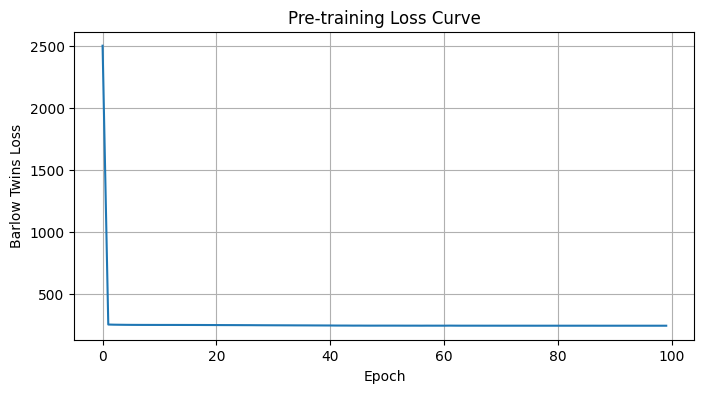

In [10]:
from tqdm import tqdm

def pretrain_barlow_twins(
    bt_model,
    train_dataset,
    aug_type='segment_mask',
    p=0.2,
    batch_size=128,
    num_epochs=100,
    lr=1e-3,
    lambda_param=10.0,
    device='cuda'
):
    """
    Self-supervised pre-training with Barlow Twins loss.
    No labels used — only sequences.
    """
    # Drop labels for pre-training
    pretrain_dataset = SequenceDataset(train_dataset.sequences.numpy())
    dataloader = DataLoader(pretrain_dataset, batch_size=batch_size, shuffle=True,
drop_last=True)

    optimizer = torch.optim.Adam(bt_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    bt_model.train()
    loss_history = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch in dataloader:
            batch = batch.to(device)

            # Generate two augmented views
            view1, view2 = apply_dual_augmentation(batch, aug_type=aug_type, p=p)
            view1, view2 = view1.to(device), view2.to(device)

            # Forward pass through shared-weight branches
            z1, z2 = bt_model(view1, view2)

            # Barlow Twins loss
            loss = barlow_twins_loss(z1, z2, lambda_param=lambda_param)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    return loss_history

# --- Run pre-training ---
# Re-initialize fresh model
user_seq_model = UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
projection_head = ProjectionHead(input_dim=16, hidden_dim=256, output_dim=256).to(device)
bt_model = BarlowTwinsModel(user_seq_model, projection_head).to(device)

print("Pre-training with Segment Masking (p=0.2)...")
loss_history = pretrain_barlow_twins(
    bt_model,
    train_dataset,
    aug_type='segment_mask',  # Best augmentation per the paper
    p=0.2,
    batch_size=128,
    num_epochs=100,
    lr=1e-3,
    lambda_param=10.0,
    device=device
)

# Save the pre-trained sequence model (discard projection head)
pretrained_seq_model = bt_model.user_seq_model
torch.save(pretrained_seq_model.state_dict(), 'pretrained_user_seq_model.pt')
print("Pre-training complete. Saved user sequence model weights.")

# --- Plot loss curve ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Barlow Twins Loss')
plt.title('Pre-training Loss Curve')
plt.grid(True)
plt.show()

DOWNSTREAM: Favorite Genre Prediction (1% labeled data)
Epoch 10/50 [frozen] | Train Acc: 0.3084 | Val Acc: 0.2672
Epoch 20/50 [frozen] | Train Acc: 0.3084 | Val Acc: 0.2672
Epoch 30/50 [frozen] | Train Acc: 0.3084 | Val Acc: 0.2672
Epoch 40/50 [frozen] | Train Acc: 0.3429 | Val Acc: 0.3312
Epoch 50/50 [frozen] | Train Acc: 0.3429 | Val Acc: 0.3312
Epoch 10/50 [trainable] | Train Acc: 0.3008 | Val Acc: 0.3297
Epoch 20/50 [trainable] | Train Acc: 0.4579 | Val Acc: 0.3347
Epoch 30/50 [trainable] | Train Acc: 0.6571 | Val Acc: 0.3431
Epoch 40/50 [trainable] | Train Acc: 0.8410 | Val Acc: 0.3515
Epoch 50/50 [trainable] | Train Acc: 0.8870 | Val Acc: 0.3571
Epoch 10/50 [trainable] | Train Acc: 0.3755 | Val Acc: 0.3150
Epoch 20/50 [trainable] | Train Acc: 0.6034 | Val Acc: 0.3575
Epoch 30/50 [trainable] | Train Acc: 0.7261 | Val Acc: 0.3794
Epoch 40/50 [trainable] | Train Acc: 0.8582 | Val Acc: 0.4059
Epoch 50/50 [trainable] | Train Acc: 0.9425 | Val Acc: 0.4126

RESULTS - Best Validation Ac

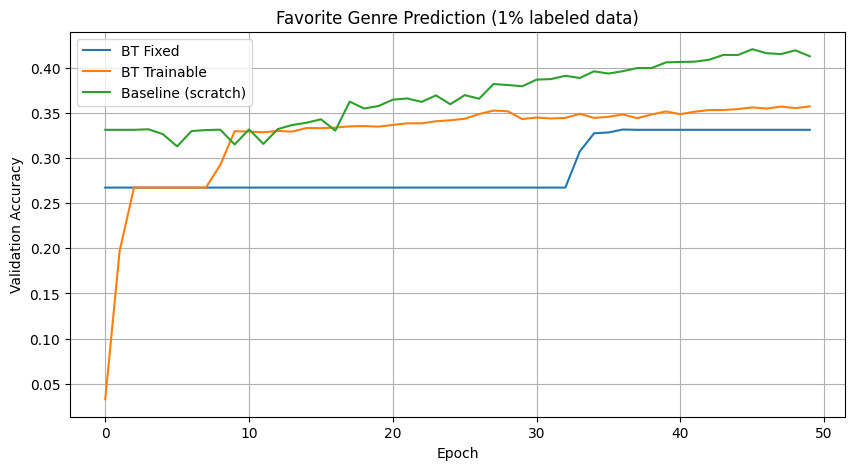

In [11]:
class DownstreamClassifier(nn.Module):
    """
    Classification head on top of the user sequence model.
    U (pre-trained) → 2-layer MLP → class logits.
    """
    def __init__(self, user_seq_model, num_classes, hidden_dim=20):
        super().__init__()
        self.user_seq_model = user_seq_model
        d_r = 16  # sequence representation dim
        self.classifier = nn.Sequential(
            nn.Linear(d_r, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        seq_repr = self.user_seq_model(x)  # (B, d_r)
        return self.classifier(seq_repr)


def train_classifier(
    model, train_dataset, val_dataset,
    num_epochs=50, batch_size=64, lr=1e-3,
    freeze_backbone=False, label_fraction=1.0, device='cuda'
):
    """
    Train a downstream classifier.

    freeze_backbone: If True, only train the classification head (fixed BT weights)
    label_fraction: Fraction of training data to use (e.g., 0.01 for 1%)
    """
    if freeze_backbone:
        for param in model.user_seq_model.parameters():
            param.requires_grad = False

    # Subsample training data to simulate limited labels
    n = len(train_dataset)
    n_use = max(batch_size, int(n * label_fraction))
    indices = np.random.permutation(n)[:n_use]
    subset = torch.utils.data.Subset(train_dataset, indices)

    train_loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            logits = model(seqs)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_accs.append(train_acc)

        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                logits = model(seqs)
                correct += (logits.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)

        best_val_acc = max(best_val_acc, val_acc)

        if (epoch + 1) % 10 == 0:
            status = "frozen" if freeze_backbone else "trainable"
            print(f"Epoch {epoch+1}/{num_epochs} [{status}] | "
                    f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return best_val_acc, train_accs, val_accs


# --- Experiment: Compare all configurations ---
print("=" * 60)
print("DOWNSTREAM: Favorite Genre Prediction (1% labeled data)")
print("=" * 60)

# 1. Barlow Twins - Fixed weights
bt_fixed_model = DownstreamClassifier(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device),
    num_classes=num_genres
).to(device)
bt_fixed_model.user_seq_model.load_state_dict(torch.load('pretrained_user_seq_model.pt', map_location=device))
bt_fixed_acc, _, bt_fixed_val = train_classifier(
    bt_fixed_model, train_dataset, val_dataset,
    num_epochs=50, freeze_backbone=True, label_fraction=0.01, device=device
)

# 2. Barlow Twins - Trainable (fine-tune all)
bt_train_model = DownstreamClassifier(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device),
    num_classes=num_genres
).to(device)
bt_train_model.user_seq_model.load_state_dict(torch.load('pretrained_user_seq_model.pt', map_location=device))
bt_train_acc, _, bt_train_val = train_classifier(
    bt_train_model, train_dataset, val_dataset,
    num_epochs=50, freeze_backbone=False, label_fraction=0.01, device=device
)

# 3. Baseline - Train from scratch
baseline_model = DownstreamClassifier(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device),
    num_classes=num_genres
).to(device)
baseline_acc, _, baseline_val = train_classifier(
    baseline_model, train_dataset, val_dataset,
    num_epochs=50, freeze_backbone=False, label_fraction=0.01, device=device
)

# --- Results ---
print("\n" + "=" * 60)
print("RESULTS - Best Validation Accuracy")
print("=" * 60)
print(f"Barlow Twins (fixed weights):  {bt_fixed_acc:.4f}")
print(f"Barlow Twins (trainable):      {bt_train_acc:.4f}")
print(f"Baseline (from scratch):       {baseline_acc:.4f}")

# --- Plot validation curves ---
plt.figure(figsize=(10, 5))
plt.plot(bt_fixed_val, label='BT Fixed')
plt.plot(bt_train_val, label='BT Trainable')
plt.plot(baseline_val, label='Baseline (scratch)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Favorite Genre Prediction (1% labeled data)')
plt.legend()
plt.grid(True)
plt.show()

DOWNSTREAM: Next-Item Prediction

--- BT Fixed ---
Epoch 10/50 [frozen] | Loss: 4.8442 | R@1: 0.0000 | R@5: 0.0002 | R@10: 0.0002
Epoch 20/50 [frozen] | Loss: 4.8357 | R@1: 0.0000 | R@5: 0.0002 | R@10: 0.0003
Epoch 30/50 [frozen] | Loss: 4.8280 | R@1: 0.0000 | R@5: 0.0000 | R@10: 0.0003
Epoch 40/50 [frozen] | Loss: 4.8193 | R@1: 0.0000 | R@5: 0.0000 | R@10: 0.0005
Epoch 50/50 [frozen] | Loss: 4.8045 | R@1: 0.0000 | R@5: 0.0000 | R@10: 0.0002

--- BT Trainable ---
Epoch 10/50 [trainable] | Loss: 4.7472 | R@1: 0.0017 | R@5: 0.0054 | R@10: 0.0096
Epoch 20/50 [trainable] | Loss: 4.6535 | R@1: 0.0032 | R@5: 0.0102 | R@10: 0.0174
Epoch 30/50 [trainable] | Loss: 4.5802 | R@1: 0.0029 | R@5: 0.0126 | R@10: 0.0216
Epoch 40/50 [trainable] | Loss: 4.5211 | R@1: 0.0023 | R@5: 0.0124 | R@10: 0.0252
Epoch 50/50 [trainable] | Loss: 4.4772 | R@1: 0.0025 | R@5: 0.0146 | R@10: 0.0265

--- Baseline (from scratch) ---
Epoch 10/50 [trainable] | Loss: 4.7341 | R@1: 0.0007 | R@5: 0.0045 | R@10: 0.0065
Epoch 2

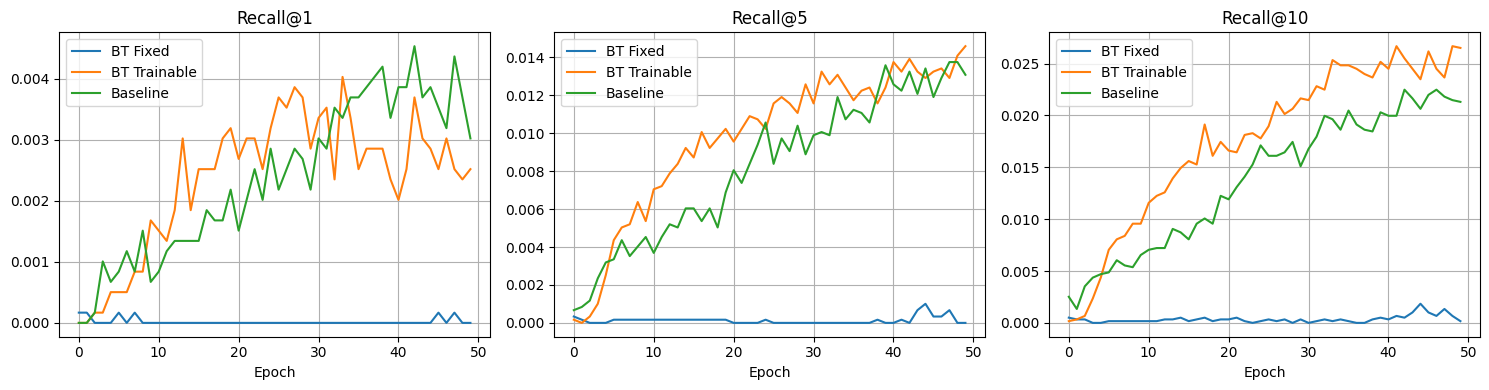

In [12]:
class DualEncoder(nn.Module):
    """
    Two-tower model for next-item prediction.
    - Context tower: U(seq[:-1]) → MLP → embedding
    - Item tower: E(target_item)
    Both share the same item embedding layer E.
    """
    def __init__(self, user_seq_model, proj_dim=16):
        super().__init__()
        self.user_seq_model = user_seq_model
        d_r = 16
        # Context MLP: project sequence repr into item embedding space
        self.context_mlp = nn.Sequential(
            nn.Linear(d_r, 32),
            nn.ReLU(),
            nn.Linear(32, proj_dim),
        )
        # Item tower shares the embedding from user_seq_model
        self.item_embedding = user_seq_model.embedding

    def encode_context(self, seq):
        """Encode a user sequence into the shared embedding space."""
        repr = self.user_seq_model(seq)        # (B, d_r)
        return F.normalize(self.context_mlp(repr), dim=-1)  # (B, proj_dim)

    def encode_items(self, item_ids):
        """Encode items into the shared embedding space."""
        emb = self.item_embedding(item_ids)     # (B, d_e)
        # Project to same dim as context if needed
        return F.normalize(emb, dim=-1)         # (B, proj_dim) — d_e == proj_dim == 16

    def forward(self, context_seq, pos_items):
        """
        context_seq: (B, seq_len) - input sequence (all but last item)
        pos_items: (B,) - ground truth next items
        Returns: contrastive loss
        """
        ctx_emb = self.encode_context(context_seq)   # (B, D)
        item_emb = self.encode_items(pos_items)      # (B, D)

        # Similarity matrix (B × B): each context vs all items in batch
        logits = torch.mm(ctx_emb, item_emb.T)       # (B, B)

        # Labels: diagonal (each context matches its own target)
        labels = torch.arange(logits.size(0), device=logits.device)

        # Cross-entropy over the batch (contrastive: positives on diagonal, rest are negatives)
        loss = F.cross_entropy(logits, labels)
        return loss


def prepare_next_item_data(sequences, mask_token=0):
    """
    Split sequences into context (all but last) and target (last item).
    Only keep sequences where the last item is not a padding token.
    """
    contexts = []
    targets = []
    for seq in sequences:
        target = seq[-1]
        if target != mask_token:
            contexts.append(list(seq[:-1]) + [mask_token])  # Pad back to same length
            targets.append(target)
    return np.array(contexts), np.array(targets)

train_ctx, train_targets = prepare_next_item_data(train_seqs)
val_ctx, val_targets = prepare_next_item_data(val_seqs)
test_ctx, test_targets = prepare_next_item_data(test_seqs)

class NextItemDataset(Dataset):
    def __init__(self, contexts, targets):
        self.contexts = torch.LongTensor(contexts)
        self.targets = torch.LongTensor(targets)
    def __len__(self):
        return len(self.contexts)
    def __getitem__(self, idx):
        return self.contexts[idx], self.targets[idx]

train_nip = NextItemDataset(train_ctx, train_targets)
val_nip = NextItemDataset(val_ctx, val_targets)
test_nip = NextItemDataset(test_ctx, test_targets)


def evaluate_recall(model, dataset, k_list=[1, 5, 10], batch_size=256, device='cuda'):
    """
    Compute top-k recall (hit-ratio) for next-item prediction.
    For each context, rank ALL items by cosine similarity and check if
    the ground truth appears in top-k.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Pre-compute all item embeddings
    all_items = torch.arange(1, num_items, device=device)  # skip MASK=0
    with torch.no_grad():
        all_item_embs = model.encode_items(all_items)  # (num_items-1, D)

    hits = {k: 0 for k in k_list}
    total = 0

    with torch.no_grad():
        for contexts, targets in loader:
            contexts, targets = contexts.to(device), targets.to(device)
            ctx_embs = model.encode_context(contexts)  # (B, D)

            # Cosine similarity: context vs all items
            sims = torch.mm(ctx_embs, all_item_embs.T)  # (B, num_items-1)

            for k in k_list:
                # Get top-k item indices (in the all_items index space)
                _, topk = sims.topk(k, dim=1)
                # Map back to actual item IDs
                topk_items = all_items[topk]  # (B, k)
                # Check if target is in top-k
                hit = (topk_items == targets.unsqueeze(1)).any(dim=1)
                hits[k] += hit.sum().item()

            total += targets.size(0)

    return {k: hits[k] / total for k in k_list}


def train_next_item_model(
    model, train_dataset, val_dataset, test_dataset,
    num_epochs=50, batch_size=128, lr=1e-3,
    freeze_backbone=False, device='cuda'
):
    """Train dual encoder for next-item prediction."""
    if freeze_backbone:
        for name, param in model.user_seq_model.named_parameters():
            if 'embedding' not in name:  # Keep embedding trainable
                param.requires_grad = False

    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_recall = {1: 0, 5: 0, 10: 0}
    history = {'train_loss': [], 'val_recall@1': [], 'val_recall@5': [], 'val_recall@10': []}

    for epoch in range(num_epochs):
        # Train
        model.train()
        epoch_loss = 0
        for contexts, targets in loader:
            contexts, targets = contexts.to(device), targets.to(device)
            loss = model(contexts, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        history['train_loss'].append(avg_loss)

        # Validate
        val_recall = evaluate_recall(model, val_dataset, k_list=[1, 5, 10], device=device)
        for k in [1, 5, 10]:
            history[f'val_recall@{k}'].append(val_recall[k])
            best_val_recall[k] = max(best_val_recall[k], val_recall[k])

        if (epoch + 1) % 10 == 0:
            status = "frozen" if freeze_backbone else "trainable"
            print(f"Epoch {epoch+1}/{num_epochs} [{status}] | Loss: {avg_loss:.4f} | R@1: {val_recall[1]:.4f} | R@5: {val_recall[5]:.4f} | R@10: {val_recall[10]:.4f}")

    # Final test evaluation
    test_recall = evaluate_recall(model, test_dataset, k_list=[1, 5, 10], device=device)

    return best_val_recall, test_recall, history


# --- Experiment: Compare configurations ---
print("=" * 60)
print("DOWNSTREAM: Next-Item Prediction")
print("=" * 60)

# 1. BT-initialized, fixed backbone
print("\n--- BT Fixed ---")
bt_fixed_nip = DualEncoder(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
).to(device)
bt_fixed_nip.user_seq_model.load_state_dict(torch.load('pretrained_user_seq_model.pt', map_location=device))
bt_fixed_val, bt_fixed_test, bt_fixed_hist = train_next_item_model(
    bt_fixed_nip, train_nip, val_nip, test_nip,
    num_epochs=50, freeze_backbone=True, device=device
)

# 2. BT-initialized, fine-tune all
print("\n--- BT Trainable ---")
bt_train_nip = DualEncoder(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
).to(device)
bt_train_nip.user_seq_model.load_state_dict(torch.load('pretrained_user_seq_model.pt', map_location=device))
bt_train_val, bt_train_test, bt_train_hist = train_next_item_model(
    bt_train_nip, train_nip, val_nip, test_nip,
    num_epochs=50, freeze_backbone=False, device=device
)

# 3. Baseline (from scratch)
print("\n--- Baseline (from scratch) ---")
baseline_nip = DualEncoder(
    UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
).to(device)
baseline_val, baseline_test, baseline_hist = train_next_item_model(
    baseline_nip, train_nip, val_nip, test_nip,
    num_epochs=50, freeze_backbone=False, device=device
)

# --- Results ---
print("\n" + "=" * 60)
print("RESULTS - Best Validation Recall (Hit-Ratio)")
print("=" * 60)
for name, val_r, test_r in [
    ("BT Fixed", bt_fixed_val, bt_fixed_test),
    ("BT Trainable", bt_train_val, bt_train_test),
    ("Baseline", baseline_val, baseline_test),
]:
    print(f"{name:20s} | Val R@1: {val_r[1]:.4f} | R@5: {val_r[5]:.4f} | R@10: {val_r[10]:.4f} "
          f"| Test R@1: {test_r[1]:.4f} | R@5: {test_r[5]:.4f} | R@10: {test_r[10]:.4f}")

# --- Plot recall curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 10]):
    ax.plot(bt_fixed_hist[f'val_recall@{k}'], label='BT Fixed')
    ax.plot(bt_train_hist[f'val_recall@{k}'], label='BT Trainable')
    ax.plot(baseline_hist[f'val_recall@{k}'], label='Baseline')
    ax.set_title(f'Recall@{k}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


Pre-training with: Random Mask (p=0.2)
Epoch 10/100 | Loss: 253.0282 | LR: 0.000976
Epoch 20/100 | Loss: 252.3232 | LR: 0.000905
Epoch 30/100 | Loss: 251.3308 | LR: 0.000794
Epoch 40/100 | Loss: 250.7345 | LR: 0.000655
Epoch 50/100 | Loss: 250.6066 | LR: 0.000500
Epoch 60/100 | Loss: 250.3527 | LR: 0.000345
Epoch 70/100 | Loss: 250.1156 | LR: 0.000206
Epoch 80/100 | Loss: 249.9792 | LR: 0.000095
Epoch 90/100 | Loss: 249.9467 | LR: 0.000024
Epoch 100/100 | Loss: 249.9372 | LR: 0.000000
Epoch 10/50 [frozen] | Train Acc: 0.2375 | Val Acc: 0.2672
Epoch 20/50 [frozen] | Train Acc: 0.3008 | Val Acc: 0.2880
Epoch 30/50 [frozen] | Train Acc: 0.3448 | Val Acc: 0.3312
Epoch 40/50 [frozen] | Train Acc: 0.3448 | Val Acc: 0.3312
Epoch 50/50 [frozen] | Train Acc: 0.3448 | Val Acc: 0.3312
Epoch 10/50 [trainable] | Loss: 4.6409 | R@1: 0.0047 | R@5: 0.0205 | R@10: 0.0366
Epoch 20/50 [trainable] | Loss: 4.5177 | R@1: 0.0059 | R@5: 0.0240 | R@10: 0.0418
Epoch 30/50 [trainable] | Loss: 4.4444 | R@1: 0.00

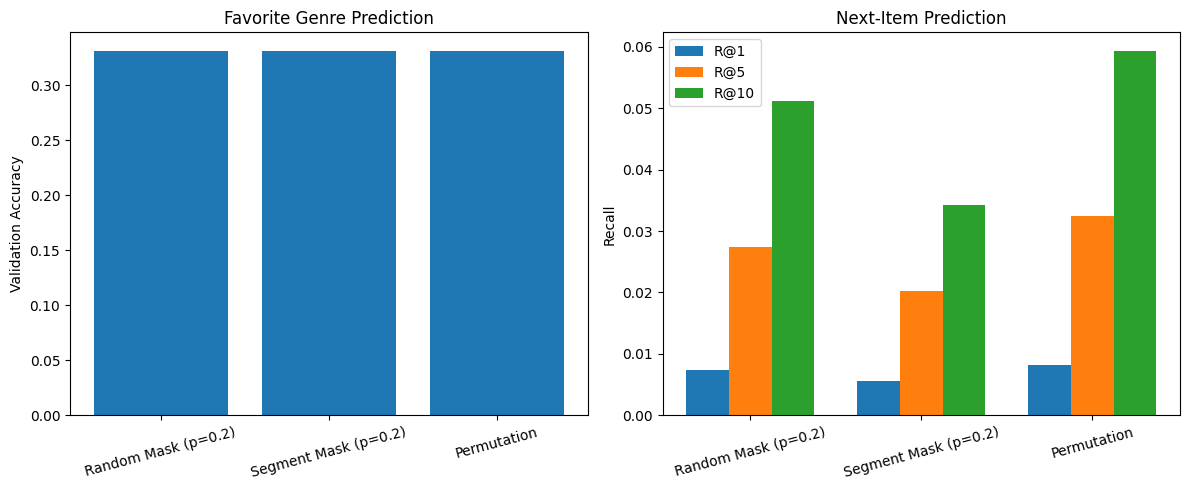

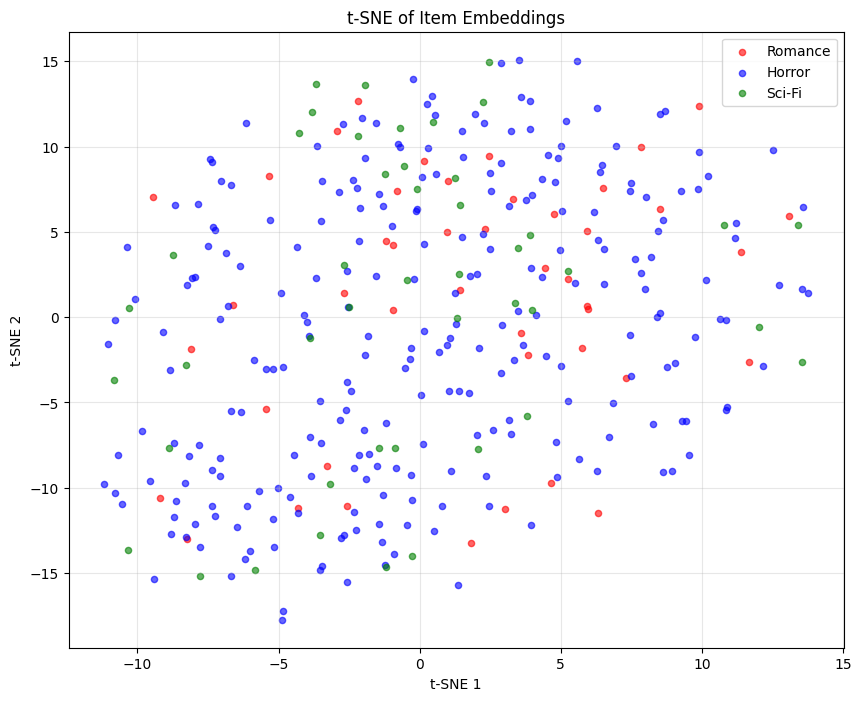

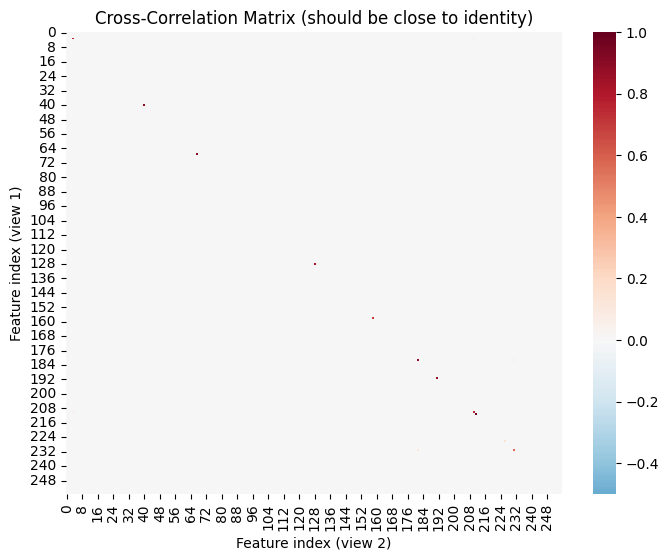

Diagonal mean: 0.0322 (target: 1.0)
Off-diagonal mean: 0.0000 (target: 0.0)

FINAL SUMMARY
Dataset: MovieLens 1M | Items: 3706 | Users: 6040
Sequences: 65343 | Seq Length: 16 | Genres: 18

Pre-training: Barlow Twins (segment masking p=0.2, 100 epochs)

Classification (1% labeled data):
  BT Fixed:     0.3315
  BT Trainable: 0.3571
  Baseline:     0.4204

Next-Item Prediction:
  BT Trainable R@5: 0.0146 | R@10: 0.0267
  Baseline     R@5: 0.0138 | R@10: 0.0225


In [13]:
from sklearn.manifold import TSNE
import seaborn as sns

# ================================================================
# 1. ABLATION: Compare augmentation strategies
# ================================================================
augmentations = [
    ('Random Mask (p=0.2)', 'random_mask', 0.2),
    ('Segment Mask (p=0.2)', 'segment_mask', 0.2),
    ('Permutation', 'permutation', None),
]

ablation_results = {}

for aug_name, aug_type, p in augmentations:
    print(f"\n{'='*50}")
    print(f"Pre-training with: {aug_name}")
    print(f"{'='*50}")

    # Fresh model for each augmentation
    um = UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
    ph = ProjectionHead(input_dim=16, hidden_dim=256, output_dim=256).to(device)
    model = BarlowTwinsModel(um, ph).to(device)

    pretrain_barlow_twins(
        model, train_dataset,
        aug_type=aug_type, p=p if p else 0.2,
        batch_size=128, num_epochs=100, device=device
    )

    # Evaluate on classification (fixed weights)
    cls_model = DownstreamClassifier(
        UserSequenceModel(num_items=num_items, embedding_dim=16).to(device),
        num_classes=num_genres
    ).to(device)
    cls_model.user_seq_model.load_state_dict(model.user_seq_model.state_dict())
    cls_acc, _, _ = train_classifier(
        cls_model, train_dataset, val_dataset,
        num_epochs=50, freeze_backbone=True, label_fraction=0.01, device=device
    )

    # Evaluate on next-item prediction (trainable)
    nip_model = DualEncoder(
        UserSequenceModel(num_items=num_items, embedding_dim=16).to(device)
    ).to(device)
    nip_model.user_seq_model.load_state_dict(model.user_seq_model.state_dict())
    nip_val, nip_test, _ = train_next_item_model(
        nip_model, train_nip, val_nip, test_nip,
        num_epochs=50, freeze_backbone=False, device=device
    )

    ablation_results[aug_name] = {
        'genre_acc': cls_acc,
        'nip_val': nip_val,
        'nip_test': nip_test,
    }

# Summary table
print("\n" + "=" * 70)
print("ABLATION RESULTS")
print("=" * 70)
print(f"{'Augmentation':<25} {'Genre Acc':>10} {'R@1':>8} {'R@5':>8} {'R@10':>8}")
print("-" * 70)
for name, res in ablation_results.items():
    print(f"{name:<25} {res['genre_acc']:>10.4f} "
          f"{res['nip_val'][1]:>8.4f} {res['nip_val'][5]:>8.4f} {res['nip_val'][10]:>8.4f}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = list(ablation_results.keys())

axes[0].bar(names, [ablation_results[n]['genre_acc'] for n in names])
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Favorite Genre Prediction')
axes[0].tick_params(axis='x', rotation=15)

x = np.arange(len(names))
width = 0.25
axes[1].bar(x - width, [ablation_results[n]['nip_val'][1] for n in names], width, label='R@1')
axes[1].bar(x, [ablation_results[n]['nip_val'][5] for n in names], width, label='R@5')
axes[1].bar(x + width, [ablation_results[n]['nip_val'][10] for n in names], width, label='R@10')
axes[1].set_ylabel('Recall')
axes[1].set_title('Next-Item Prediction')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()


# ================================================================
# 2. t-SNE VISUALIZATION of item embeddings
# ================================================================
def plot_tsne_embeddings(model, movies_df, item2idx, idx2item, genres_to_plot=None):
    """
    Visualize item embeddings colored by genre using t-SNE.
    The paper compared BT vs dual encoder embeddings.
    """
    if genres_to_plot is None:
        genres_to_plot = ['Romance', 'Horror', 'Sci-Fi']

    model.eval()
    with torch.no_grad():
        # Get all item embeddings (skip MASK at index 0)
        all_embs = model.embedding.weight[1:].cpu().numpy()

    # Map each embedding to its genre
    genres = []
    valid_indices = []
    for idx in range(1, len(all_embs) + 1):
        orig_id = idx2item.get(idx)
        if orig_id:
            genre = movies_df[movies_df['movie_id'] == orig_id]['genres'].values
            if len(genre) > 0:
                primary_genre = genre[0].split('|')[0]
                if primary_genre in genres_to_plot:
                    genres.append(primary_genre)
                    valid_indices.append(idx - 1)

    if len(valid_indices) < 10:
        print("Not enough items with matching genres for t-SNE")
        return

    embs_subset = all_embs[valid_indices]

    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(valid_indices)-1))
    coords = tsne.fit_transform(embs_subset)

    # Plot
    plt.figure(figsize=(10, 8))
    genre_colors = {g: c for g, c in zip(genres_to_plot, ['red', 'blue', 'green', 'purple', 'orange'])}
    for genre in genres_to_plot:
        mask = [g == genre for g in genres]
        plt.scatter(coords[mask, 0], coords[mask, 1],
                    c=genre_colors[genre], label=genre, alpha=0.6, s=20)
    plt.legend()
    plt.title('t-SNE of Item Embeddings')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot BT embeddings
plot_tsne_embeddings(bt_fixed_nip.user_seq_model, movies, item2idx, idx2item)


# ================================================================
# 3. CROSS-CORRELATION MATRIX HEATMAP
# ================================================================
def visualize_cross_correlation(bt_model, dataset, aug_type='segment_mask', p=0.2, device='cuda'):
    """
    Compute and visualize the cross-correlation matrix C.
    Should be close to identity if pre-training converged well.
    """
    bt_model.eval()
    loader = DataLoader(SequenceDataset(dataset.sequences.numpy()), batch_size=256, shuffle=True)
    batch = next(iter(loader)).to(device)

    v1, v2 = apply_dual_augmentation(batch, aug_type=aug_type, p=p)
    v1, v2 = v1.to(device), v2.to(device)

    with torch.no_grad():
        z1, z2 = bt_model(v1, v2)
        z1 = z1 - z1.mean(dim=0)
        z2 = z2 - z2.mean(dim=0)
        c = torch.mm(z1.T, z2) / z1.size(0)
        std_z1 = torch.sqrt(z1.var(dim=0) + 1e-5)
        std_z2 = torch.sqrt(z2.var(dim=0) + 1e-5)
        c = c / (std_z1.unsqueeze(1) * std_z2.unsqueeze(0) + 1e-8)

    c_np = c.cpu().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(c_np, cmap='RdBu_r', center=0, vmin=-0.5, vmax=1.0)
    plt.title('Cross-Correlation Matrix (should be close to identity)')
    plt.xlabel('Feature index (view 2)')
    plt.ylabel('Feature index (view 1)')
    plt.show()

    # Summary stats
    diag = np.diag(c_np)
    off_diag = c_np[~np.eye(c_np.shape[0], dtype=bool)]
    print(f"Diagonal mean: {diag.mean():.4f} (target: 1.0)")
    print(f"Off-diagonal mean: {np.abs(off_diag).mean():.4f} (target: 0.0)")

visualize_cross_correlation(bt_model, train_dataset, aug_type='segment_mask', p=0.2)


# ================================================================
# 4. FINAL SUMMARY
# ================================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Dataset: MovieLens 1M | Items: {num_items-1} | Users: {len(user_sequences)}")
print(f"Sequences: {len(sequences)} | Seq Length: {SEQ_LEN} | Genres: {num_genres}")
print(f"\nPre-training: Barlow Twins (segment masking p=0.2, 100 epochs)")
print(f"\nClassification (1% labeled data):")
print(f"  BT Fixed:     {bt_fixed_acc:.4f}")
print(f"  BT Trainable: {bt_train_acc:.4f}")
print(f"  Baseline:     {baseline_acc:.4f}")
print(f"\nNext-Item Prediction:")
print(f"  BT Trainable R@5: {bt_train_val[5]:.4f} | R@10: {bt_train_val[10]:.4f}")
print(f"  Baseline     R@5: {baseline_val[5]:.4f} | R@10: {baseline_val[10]:.4f}")